# That nasty integral

I need to solve this integral:

$$I= \int_0^\infty x^3 \exp\left(-\frac{x^2}{2\sigma^2}\right) \,dx = 2\sigma^4 .$$

The Gaussian pdf with mean=0 is

$$\frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{x^2}{2\sigma^2}\right)$$

which is normalized between $-\infty$ and $+\infty$. Here we want a half Gaussian

$$p(x) = \frac{2}{\sigma\sqrt{2\pi}} \exp\left(-\frac{x^2}{2\sigma^2}\right)$$

which correctly gives $\int_0^\infty p(x) =1$. My integral then becomes

$$I = \sigma\sqrt\frac{\pi}{2} \int_0^\infty x^3 p(x) dx $$



In [4]:
import numpy as np
import scipy.stats
import pylab as plt
from tqdm.notebook import tqdm

First generate from a Gaussian

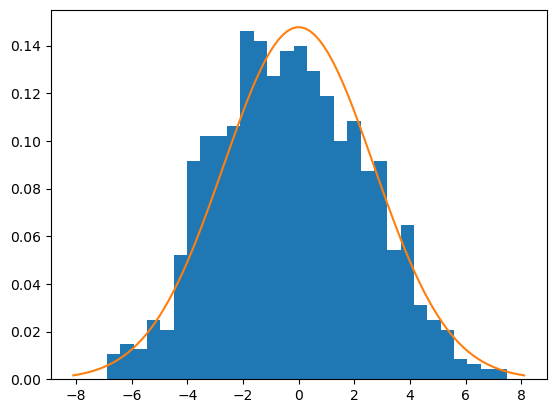

In [5]:
sigma=2.7
N=1000

gauss = scipy.stats.norm(loc=0,scale=sigma)

plt.hist(gauss.rvs(N),density=True,bins=30);
plt.plot(np.linspace(-3*sigma,3*sigma,100), gauss.pdf(np.linspace(-3*sigma,3*sigma,100)))

The Gaussian distribution is symmetric. To generate points from a half-gaussian it's enough to take the abs.

In [6]:
gauss.rvs(N)

array([-1.38693074e+00, -2.37912185e+00, -9.63974950e-01, -2.26136414e+00,
        2.50282012e+00,  2.87948432e+00, -2.14128430e+00, -1.32270572e+00,
        2.66174225e+00,  5.59562330e+00,  3.61726794e+00,  1.42917333e+00,
       -1.35622698e-01, -4.01066400e+00, -8.43674971e-01,  4.15510013e+00,
        5.60261761e+00,  5.00533073e-01, -7.65148284e-01, -4.50414820e+00,
        2.73400265e+00,  2.10803193e+00,  3.28516687e+00, -1.42302825e+00,
       -9.34233614e-02,  3.12107365e+00,  8.03853487e-01, -2.76014127e+00,
       -8.72273642e-01, -5.96317022e-01,  5.89445826e-01,  8.51516714e-01,
       -1.75053091e+00, -9.88407789e-01,  1.01128259e-01, -7.74142412e-01,
        4.68551611e-01, -4.84050120e+00,  1.55625458e+00, -2.91397837e+00,
       -7.15229584e-01, -5.47144900e+00,  3.41353090e-01, -1.09491186e+00,
       -3.28404456e+00, -7.45953999e-01,  3.18778337e+00,  1.90608104e+00,
        7.27861060e-01, -1.07336646e+00,  2.67355135e+00,  1.29057999e+00,
        1.42199603e+00,  

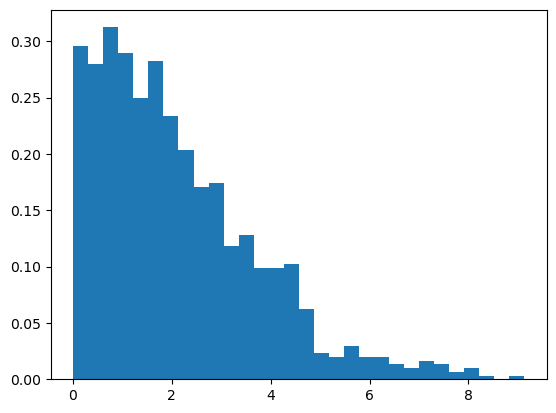

In [7]:
plt.hist(np.abs(gauss.rvs(N)),density=True,bins=30);
#plt.plot(np.linspace(0,3*sigma,100), 2*gauss.pdf(np.linspace(0,3*sigma,100)))

Ok now I can do the Monte Carlo magic

In [8]:
samples = np.abs(gauss.rvs(N))
I = sigma*(np.pi/2)**0.5 * np.mean(samples**3)
knownresult= 2*sigma**4 

print(I,knownresult, np.abs(I-knownresult)/knownresult)

115.68228389275231 106.28820000000003 0.08838313089084465


Ok it works. Put this into a function now




In [9]:
def integral(sigma,N):
    gauss = scipy.stats.norm(loc=0,scale=sigma)
    samples = np.abs(gauss.rvs(N))
    norm = sigma*(np.pi/2)**0.5
    return norm * np.mean(samples**3) #, norm * scipy.stats.tstd(samples**3) / N**0.5

def knownresult(sigma):
    return 2*sigma**4  

In [10]:
sigma = 0.45
Nvals=np.unique(np.logspace(0,6,100,dtype=int))
Nvals

array([      1,       2,       3,       4,       5,       6,       7,
             8,       9,      10,      12,      14,      16,      18,
            21,      24,      28,      32,      37,      43,      49,
            57,      65,      75,      86,     100,     114,     132,
           151,     174,     200,     231,     265,     305,     351,
           403,     464,     533,     613,     705,     811,     932,
          1072,    1232,    1417,    1629,    1873,    2154,    2477,
          2848,    3274,    3764,    4328,    4977,    5722,    6579,
          7564,    8697,   10000,   11497,   13219,   15199,   17475,
         20092,   23101,   26560,   30538,   35111,   40370,   46415,
         53366,   61359,   70548,   81113,   93260,  107226,  123284,
        141747,  162975,  187381,  215443,  247707,  284803,  327454,
        376493,  432876,  497702,  572236,  657933,  756463,  869749,
       1000000])

In [11]:
results = np.array([integral(sigma,N) for N in tqdm(Nvals)])

  0%|          | 0/92 [00:00<?, ?it/s]

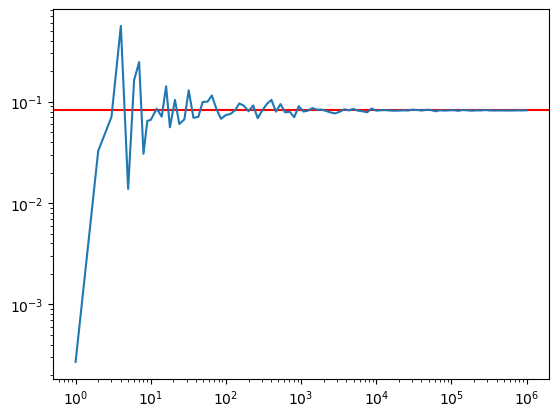

In [12]:
plt.axhline(knownresult(sigma),c='red')
plt.plot(Nvals,results)
plt.loglog()
plt.show()

It converges to the right thing! Nice. Now what's the error?

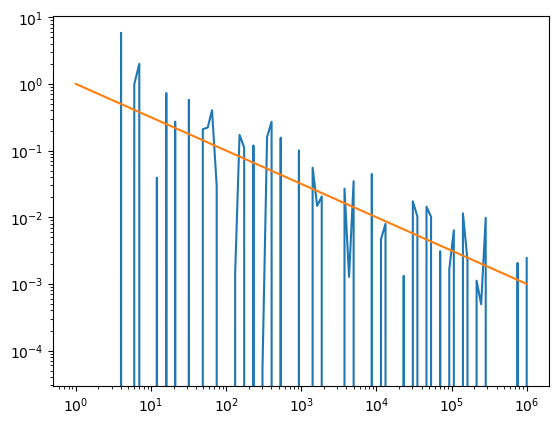

In [13]:
plt.axhline(0,c='red')
plt.plot(Nvals, (results - knownresult(sigma))/knownresult(sigma))
plt.plot(Nvals, Nvals**-0.5)

plt.loglog()
plt.show()

The error goes down as $1/\sqrt N$ as expected.

How's my estimate distributed? Let's repeat for many realizations:

In [14]:
N=1000
realizations = 10000
results = np.array([integral(sigma,N) for i in tqdm(range(realizations))])

  0%|          | 0/10000 [00:00<?, ?it/s]

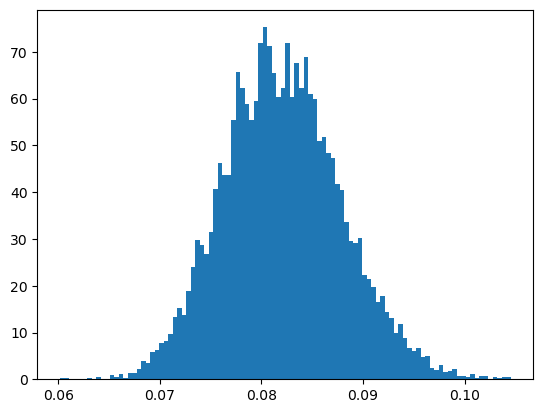

In [15]:
plt.hist(results,density=True, bins=100);

Wow. That looks really gaussian. A poor's man fit using sample mean and standard deviation

In [16]:
mean = np.average(results)
std = np.std(results, ddof=1)

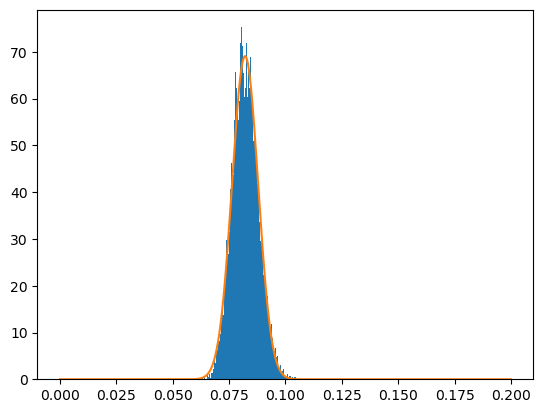

In [17]:
plt.hist(results,density=True, bins=100);
gauss = scipy.stats.norm(loc=mean,scale=std)
x = np.linspace(0,0.2,1000)
plt.plot(x,gauss.pdf(x));

# Horses in the prussian army

In [18]:
import numpy as np
import pylab as plt
import  scipy.stats

In [19]:
deaths = np.array([0,1,2,3,4])
groups = np.array([109,65,22,3,1])

In [20]:
tot = np.sum(groups)

In [21]:
tot

np.int64(200)

In [22]:
freq = groups/tot

Just plotting the data (careful with the normalization)

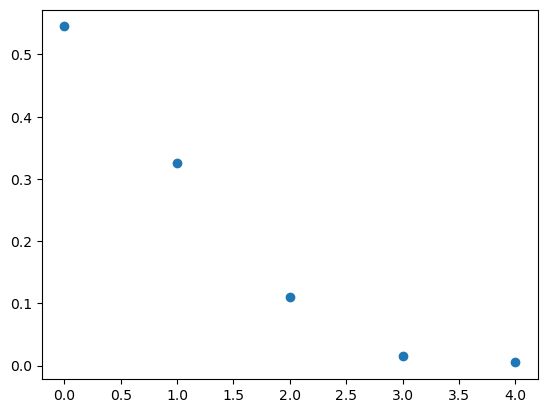

In [23]:
plt.scatter(deaths, freq)

Try some Poisson distributions

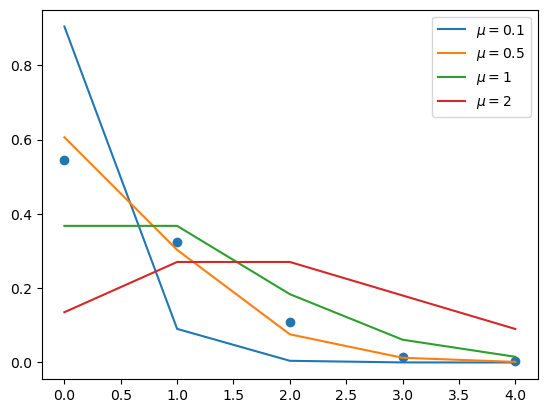

In [ ]:
plt.scatter(deaths, freq)

for mu in [0.1,0.5,1,2]:
    p = scipy.stats.poisson(mu).pmf(deaths)
    plt.plot(deaths, p,label='$\mu='+str(mu)+"$")
plt.legend()

A poor's man fit using the sample mean

In [25]:
goodmu = np.average(deaths,weights=freq)

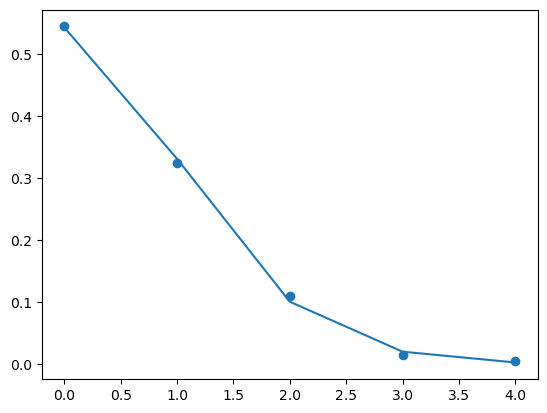

In [26]:
plt.scatter(deaths, freq)

p = scipy.stats.poisson(goodmu).pmf(deaths)
plt.plot(deaths, p)

... which fits very well!